### Read SNOWPACK Output at PPSA with HRRR-AK WY2020-WY2025

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [15]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [16]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/ppsa'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [17]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [18]:
ds_snowpack_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
# ds_snowpack_met_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet")
# ds_snowpack_met_hrrrak_ffill, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ffill_ppsa_WY2020-WY2025_base.smet")

/tmp/ipykernel_2733555/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


### Open Observations

In [28]:
# # open observations
file = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs = xr.open_dataset(file)

# ds_obs = ds_obs.sel(time=slice("2019-10-01", "2022-09-30"))
ds_obs = ds_obs.sel(time=slice("2020-01-10", "2025-09-30"))
# ds_obs


In [29]:
# ds_snowpack_hrrrak
# ds_snowpack_met_hrrrak

Text(0, 0.5, 'snow depth (cm)')

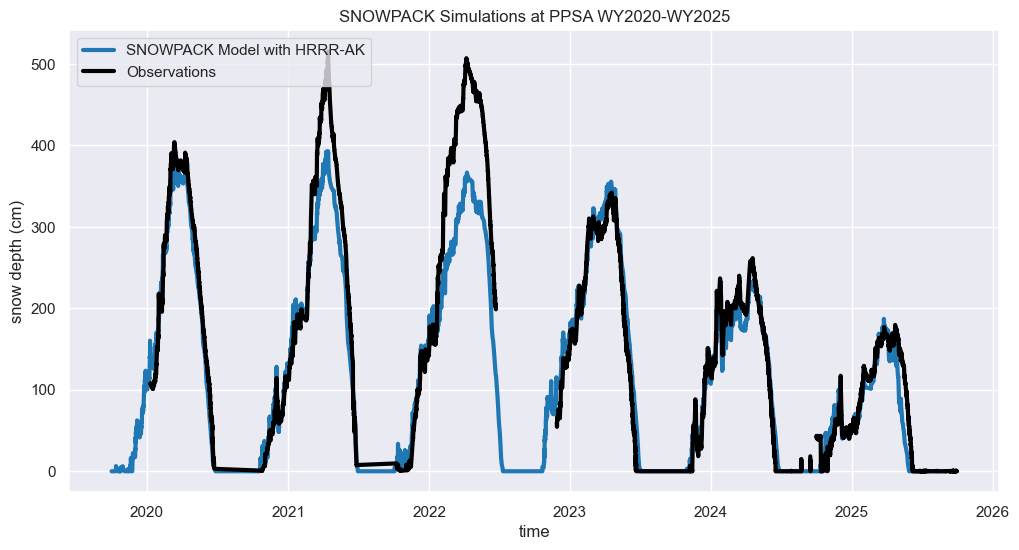

In [30]:
ds_snowpack_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
# ds_snowpack_met_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')

ds_obs.hs.plot(label = 'Observations', linewidth = 3, color='black')


plt.title('SNOWPACK Simulations at PPSA WY2020-WY2025')
plt.legend(loc = 'upper left')

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

### SWE

Text(0, 0.5, 'SWE (mm)')

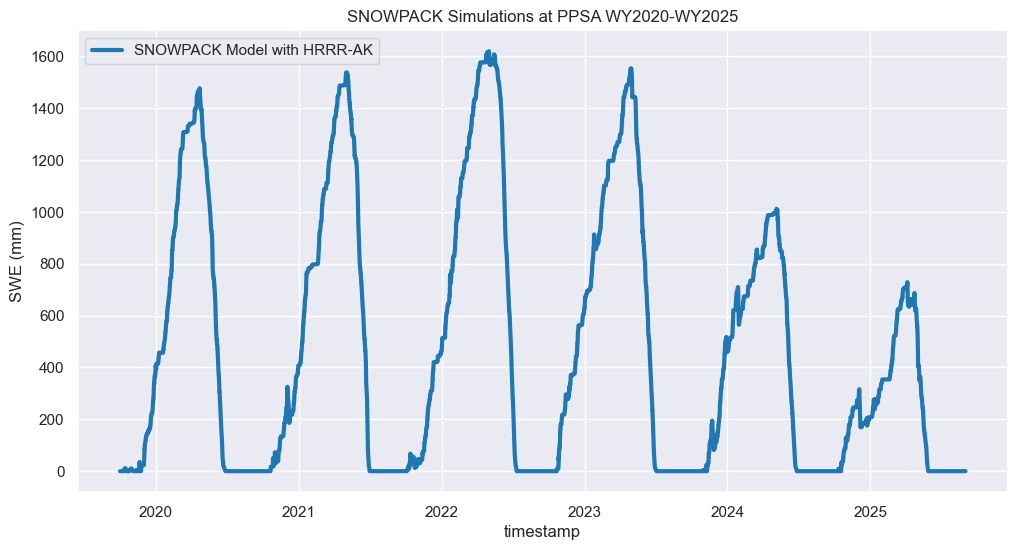

In [13]:
ds_snowpack_hrrrak.SWE.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
# ds_snowpack_met_hrrrak.SWE.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.SWE.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')

# (ds_obs.swe*10).plot(label = 'Observations', linewidth = 3, color='black') # convert SWE to mm 


plt.title('SNOWPACK Simulations at PPSA WY2020-WY2025')
plt.legend(loc = 'upper left')

# plt.ylim([-10, 300])

plt.ylabel('SWE (mm)')

Yeah, that kinda anwsers my questions...